In [1]:
import pandas as pd
import numpy as np
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

conn = sqlite3.connect('../instacart.db')
os.makedirs('../exports', exist_ok=True)
print("Ready!")

Ready!


In [2]:
# Pull order volume by department + day of week
dept_dow = pd.read_sql("""
    SELECT 
        d.department,
        o.order_dow,
        o.order_hour_of_day,
        COUNT(*) as volume
    FROM order_products_prior op
    JOIN orders o ON op.order_id = o.order_id
    JOIN products p ON op.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    GROUP BY d.department, o.order_dow, o.order_hour_of_day
""", conn)

print(dept_dow.shape)
print(dept_dow.head())

(3528, 4)
  department  order_dow  order_hour_of_day  volume
0    alcohol          0                  0      52
1    alcohol          0                  1      39
2    alcohol          0                  2      26
3    alcohol          0                  3      27
4    alcohol          0                  4      37


In [3]:
# Instacart has no real dates — we create 26 weeks respecting dow pattern
np.random.seed(42)
start = pd.Timestamp('2024-01-01')

def dow_to_date(dow, week_num):
    # Find the date in that week matching the day of week
    week_start = start + pd.Timedelta(weeks=int(week_num))
    return week_start + pd.Timedelta(days=int(dow))

# Assign each row a week randomly across 26 weeks
dept_dow['week'] = np.random.randint(0, 26, size=len(dept_dow))
dept_dow['date'] = dept_dow.apply(
    lambda r: dow_to_date(r['order_dow'], r['week']), axis=1)

# Aggregate to daily total per department
daily = (dept_dow.groupby(['department', 'date'])['volume']
         .sum()
         .reset_index()
         .sort_values(['department', 'date']))

print(daily['department'].unique())
print(daily.shape)

<StringArray>
[        'alcohol',          'babies',          'bakery',       'beverages',
       'breakfast',            'bulk',    'canned goods',      'dairy eggs',
            'deli', 'dry goods pasta',          'frozen',       'household',
   'international',    'meat seafood',         'missing',           'other',
          'pantry',   'personal care',            'pets',         'produce',
          'snacks']
Length: 21, dtype: str
(2339, 3)


In [4]:
%pip install prophet

from prophet import Prophet

departments = ['produce', 'dairy eggs', 'beverages', 'snacks', 'frozen']
forecasts = {}

for dept in departments:
    df = daily[daily['department'] == dept][['date','volume']].copy()
    df.columns = ['ds', 'y']
    df = df.groupby('ds')['y'].sum().reset_index()
    
    m = Prophet(
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1
    )
    m.fit(df)
    
    future = m.make_future_dataframe(periods=7)
    fc = m.predict(future)
    forecasts[dept] = fc[['ds','yhat','yhat_lower','yhat_upper']].tail(7).copy()
    forecasts[dept]['department'] = dept
    print(f"✓ {dept}")

print("\nAll forecasts done!")

  Using cached prophet-1.3.0-py3-none-macosx_11_0_arm64.whl.metadata (3.5 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-macosx_11_0_arm64.whl (12.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.2 MB/s  0:00:00 eta 0:00:01
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [prophet]m5/6 [prophet]y]
Note: you may need to restart the kernel to use updated packages.


Importing plotly failed. Interactive plots will not work.
17:15:14 - cmdstanpy - INFO - Chain [1] start processing
17:15:15 - cmdstanpy - INFO - Chain [1] done processing
17:15:15 - cmdstanpy - INFO - Chain [1] start processing
17:15:15 - cmdstanpy - INFO - Chain [1] done processing
17:15:15 - cmdstanpy - INFO - Chain [1] start processing
17:15:15 - cmdstanpy - INFO - Chain [1] done processing
17:15:15 - cmdstanpy - INFO - Chain [1] start processing
17:15:15 - cmdstanpy - INFO - Chain [1] done processing


✓ produce
✓ dairy eggs
✓ beverages


17:15:15 - cmdstanpy - INFO - Chain [1] start processing
17:15:15 - cmdstanpy - INFO - Chain [1] done processing


✓ snacks
✓ frozen

All forecasts done!


In [5]:
# Simulated baseline stock per department (dark store inventory)
baseline_stock = {
    'produce': 5000,
    'dairy eggs': 4000,
    'beverages': 6000,
    'snacks': 3500,
    'frozen': 2800
}

rows = []
for dept, fc in forecasts.items():
    for _, row in fc.iterrows():
        demand = max(row['yhat'], 0)
        stock = baseline_stock[dept]
        risk_pct = round((demand / stock) * 100, 1)
        risk_level = ('HIGH' if risk_pct > 85
                      else 'MEDIUM' if risk_pct > 60
                      else 'LOW')
        rows.append({
            'date': row['ds'].date(),
            'department': dept,
            'predicted_demand': round(demand),
            'yhat_lower': round(max(row['yhat_lower'], 0)),
            'yhat_upper': round(row['yhat_upper']),
            'stock_baseline': stock,
            'stockout_risk_pct': risk_pct,
            'risk_level': risk_level
        })

risk_df = pd.DataFrame(rows)
print(risk_df)

          date  department  predicted_demand  yhat_lower  yhat_upper  \
0   2024-07-01     produce            155661       66625      239338   
1   2024-07-02     produce            127536       36208      222195   
2   2024-07-03     produce             73432           0      164307   
3   2024-07-04     produce             76010           0      164073   
4   2024-07-05     produce             80823           0      172403   
5   2024-07-06     produce             89761        5118      178529   
6   2024-07-07     produce             88689        5142      178461   
7   2024-07-01  dairy eggs             77114       23167      132785   
8   2024-07-02  dairy eggs             66379       10916      117039   
9   2024-07-03  dairy eggs             48009           0      106673   
10  2024-07-04  dairy eggs             38370           0       91150   
11  2024-07-05  dairy eggs             37794           0       92219   
12  2024-07-06  dairy eggs             45478           0      10

In [6]:
risk_df.to_csv('../exports/stockout_risk_7day.csv', index=False)
risk_df.to_excel('../exports/stockout_risk_7day.xlsx', index=False)

# Also save full daily demand for Power BI trend chart
daily[daily['department'].isin(departments)].to_csv(
    '../exports/daily_demand_history.csv', index=False)

print("✓ stockout_risk_7day.csv")
print("✓ stockout_risk_7day.xlsx")
print("✓ daily_demand_history.csv")

✓ stockout_risk_7day.csv
✓ stockout_risk_7day.xlsx
✓ daily_demand_history.csv


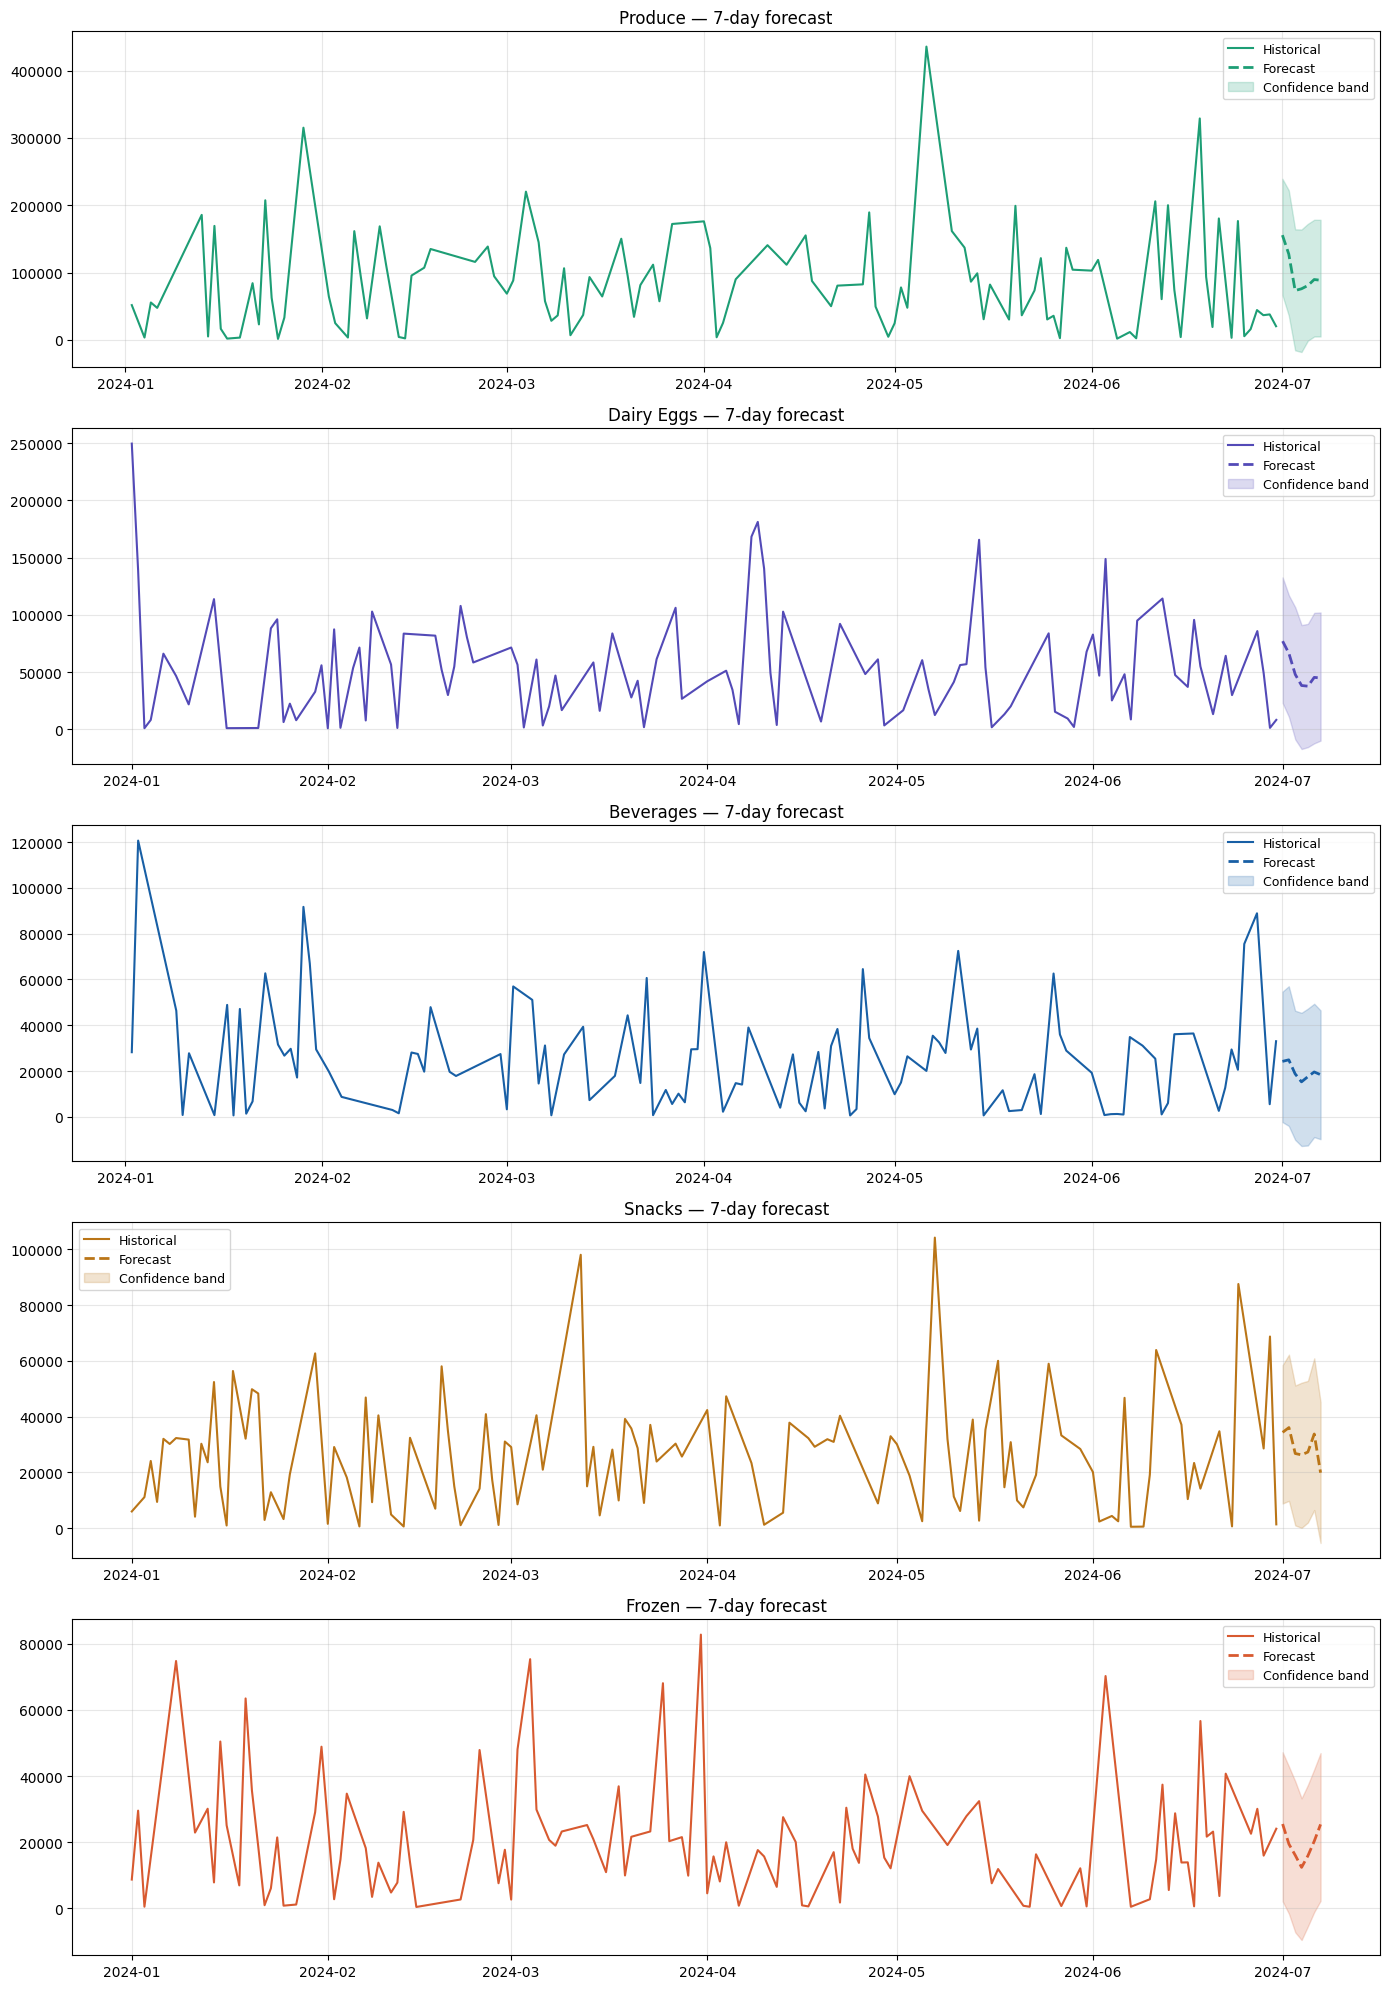

✓ Saved forecast chart


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(14, 20))

colors = {'produce':'#1D9E75','dairy eggs':'#534AB7',
          'beverages':'#185FA5','snacks':'#BA7517','frozen':'#D85A30'}

for ax, dept in zip(axes, departments):
    hist = daily[daily['department']==dept].groupby('date')['volume'].sum()
    fc = forecasts[dept]
    
    ax.plot(hist.index, hist.values, color=colors[dept], label='Historical', linewidth=1.5)
    ax.plot(pd.to_datetime(fc['ds']), fc['yhat'],
            color=colors[dept], linestyle='--', label='Forecast', linewidth=2)
    ax.fill_between(pd.to_datetime(fc['ds']),
                    fc['yhat_lower'], fc['yhat_upper'],
                    alpha=0.2, color=colors[dept], label='Confidence band')
    ax.set_title(f'{dept.title()} — 7-day forecast', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../exports/08_forecast_by_dept.png', dpi=150)
plt.show()
print("✓ Saved forecast chart")

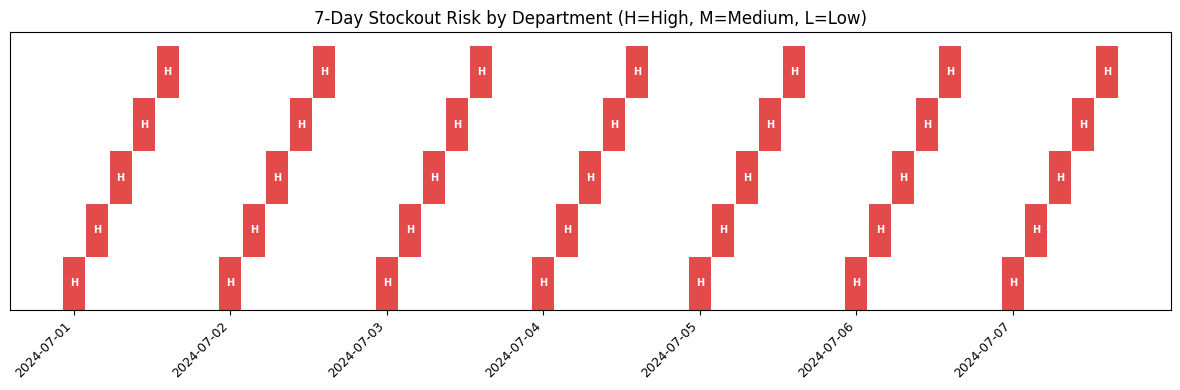

In [8]:
pivot = risk_df.pivot(index='department', columns='date', values='risk_level')

color_map = {'LOW': '#1D9E75', 'MEDIUM': '#BA7517', 'HIGH': '#E24B4A'}

fig, ax = plt.subplots(figsize=(12, 4))
for i, dept in enumerate(pivot.index):
    for j, date in enumerate(pivot.columns):
        level = pivot.loc[dept, date]
        ax.bar(j + i*0.15, 1, bottom=i,
               color=color_map.get(level, 'gray'), width=0.14)
        ax.text(j + i*0.15, i + 0.5, level[0],
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(d) for d in pivot.columns], rotation=45, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('7-Day Stockout Risk by Department (H=High, M=Medium, L=Low)')
plt.tight_layout()
plt.savefig('../exports/09_stockout_risk_heatmap.png', dpi=150)
plt.show()